In [1]:
import tensorflow as tf 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

I0000 00:00:1787121770.261227   16818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787121770.296650   16818 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787121771.896340   16818 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(train_images,train_labels),(test_images,test_labels) = tf.keras.datasets.mnist.load_data()

print(f"Training data shape:{train_images.shape}, Training labels shape:{train_labels.shape}")
print(f"Test data shape:{test_images.shape}, Test labels shape:{test_labels.shape}")

Training data shape:(60000, 28, 28), Training labels shape:(60000,)
Test data shape:(10000, 28, 28), Test labels shape:(10000,)


In [3]:
# Normalize the images to a range of 0 to 1 by dividing by 255.0

train_images,test_images = train_images/255.0,test_images/255.0

# Split the training data into training and validation sets
train_images,val_images,train_labels,val_labels = train_test_split(train_images,train_labels,test_size = 0.2,
                                                                   random_state = 42)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)), # Flatten layer
    tf.keras.layers.Dense(128,activation='relu'), # Hidden dense layer with relu activation
    tf.keras.layers.Dense(10,activation='softmax')]) # Output dense layer with Softmax activation


model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])


/home/bhoopender/tensorflow/tensorflow/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1787122152.090172   16818 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2604 MB memory:  -> device: 0, name: NVIDIA T1000, pci bus id: 0000:01:00.0, compute capability: 7.5


In [5]:
history = model.fit(train_images,train_labels,epochs = 10,validation_data = (val_images,val_labels))


Epoch 1/10


I0000 00:00:1787123127.480785   17775 service.cc:153] XLA service 0x7ad1700428e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787123127.480801   17775 service.cc:161]   StreamExecutor [0]: NVIDIA T1000, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1787123127.821272   17775 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787123128.220945   17775 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1787123128.288036   17775 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_919__.12


 143/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6390 - loss: 1.2207

I0000 00:00:1787123130.943414   17775 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9177 - loss: 0.2889 - val_accuracy: 0.9543 - val_loss: 0.1626
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9620 - loss: 0.1318 - val_accuracy: 0.9651 - val_loss: 0.1230
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9732 - loss: 0.0904 - val_accuracy: 0.9687 - val_loss: 0.1041
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9797 - loss: 0.0670 - val_accuracy: 0.9702 - val_loss: 0.0964
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9847 - loss: 0.0514 - val_accuracy: 0.9663 - val_loss: 0.1050
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9874 - loss: 0.0409 - val_accuracy: 0.9718 - val_loss: 0.0932
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9906 - loss: 0.0320 - val_accuracy: 0.9763 - val_loss: 0.0873
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9916 - loss: 0.0266 - val_accurac

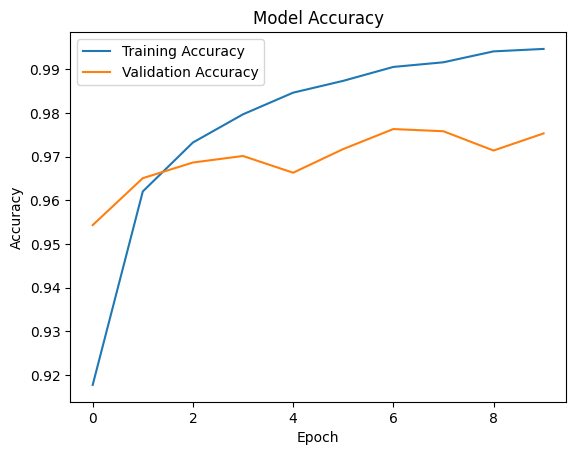

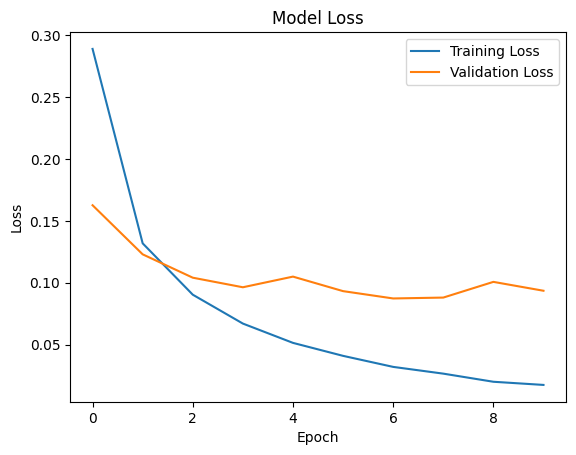

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
test_loss,test_accuracy = model.evaluate(test_images,test_labels)

print(f"Test Loss: {test_loss:<10.4f}, Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9760 - loss: 0.0880
Test Loss: 0.0880    , Test Accuracy: 0.9760
